In [78]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [79]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [80]:
NUM_CLASSES = 27

# Dataset reading

In [81]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [82]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [84]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [85]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_8 (Dropout)         (None, 42)                0         
                                                                 
 dense_12 (Dense)            (None, 20)                860       
                                                                 
 dropout_9 (Dropout)         (None, 20)                0         
                                                                 
 dense_13 (Dense)            (None, 10)                210       
                                                                 
 dense_14 (Dense)            (None, 27)                297       
                                                                 
Total params: 1,367
Trainable params: 1,367
Non-trainable params: 0
_________________________________________________________________


In [86]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [87]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [88]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
1/9 [==>...........................] - ETA: 1s - loss: 3.3626 - accuracy: 0.0078
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
9/9 [==============================] - 0s 27ms/step - loss: 3.3399 - accuracy: 0.0081 - val_loss: 3.2790 - val_accuracy: 0.0188
Epoch 2/1000
1/9 [==>...........................] - ETA: 0s - loss: 3.2939 - accuracy: 0.0469
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
9/9 [==============================] - 0s 3ms/step - loss: 3.2546 - accuracy: 0.0519 - val_loss: 3.2152 - val_accuracy: 0.2118
Epoch 3/1000
1/9 [==>...........................] - ETA: 0s - loss: 3.2058 - accuracy: 0.0312
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
9/9 [==============================] - 0s 3ms/step - loss: 3.1863 - accuracy: 0.0761 - val_loss: 3.1420 - val_accuracy: 0.2011
Epoch 4/1000
1/9 [==>...........................] - ETA: 0s - loss: 3.1668 - accuracy: 0.0781
Epoch 4: savin

In [89]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

3/3 [==============================] - 0s 695us/step - loss: 0.2434 - accuracy: 0.9625


In [90]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [91]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 26ms/step
[3.05646062e-02 1.09698121e-04 1.49477899e-07 8.72327387e-01
 9.69977602e-02 4.27028255e-07 1.10329966e-11 4.66703119e-13
 8.09440947e-15 1.99505753e-14 1.03353188e-12 2.61332349e-16
 3.82775374e-11 8.79554830e-16 1.99301592e-17 1.71499994e-13
 1.20714636e-12 9.00021423e-16 8.22689326e-16 1.12979198e-17
 2.48034964e-16 1.69519715e-17 1.33246568e-16 2.13627194e-15
 1.60866592e-15 4.62138281e-18 1.88224358e-14]
3


# Confusion matrix

12/12 [==============================] - 0s 449us/step


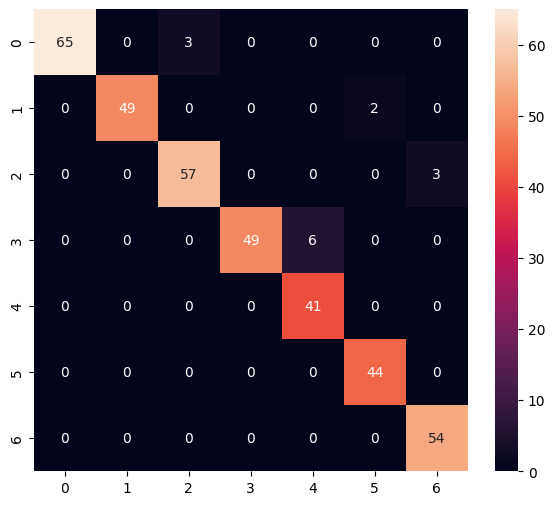

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        68
           1       1.00      0.96      0.98        51
           2       0.95      0.95      0.95        60
           3       1.00      0.89      0.94        55
           4       0.87      1.00      0.93        41
           5       0.96      1.00      0.98        44
           6       0.95      1.00      0.97        54

    accuracy                           0.96       373
   macro avg       0.96      0.97      0.96       373
weighted avg       0.97      0.96      0.96       373



In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [93]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [94]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpjnzrlx55/assets


INFO:tensorflow:Assets written to: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpjnzrlx55/assets
2022-12-04 17:24:50.939696: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2022-12-04 17:24:50.939710: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.
2022-12-04 17:24:50.939786: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpjnzrlx55
2022-12-04 17:24:50.940574: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2022-12-04 17:24:50.940580: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /var/folders/q0/fdvgrzp961n62fnzd8js90cm0000gn/T/tmpjnzrlx55
2022-12-04 17:24:50.943025: I tensorflow/cc/saved_model/loader.cc:229] Restoring SavedModel bundle.
2022-12-04 17:24:50.967634: I tensorflow/cc/saved_model/loader.cc:213] Running initialization

7620

# Inference test

In [95]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [96]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [97]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [98]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 23 µs, sys: 2 µs, total: 25 µs
Wall time: 26.7 µs


In [99]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[3.0564601e-02 1.0969843e-04 1.4947759e-07 8.7232727e-01 9.6997932e-02
 4.2702899e-07 1.1032995e-11 4.6670214e-13 8.0943773e-15 1.9950572e-14
 1.0335318e-12 2.6133132e-16 3.8277458e-11 8.7955472e-16 1.9930080e-17
 1.7149997e-13 1.2071416e-12 9.0002132e-16 8.2268922e-16 1.1297918e-17
 2.4803398e-16 1.6951970e-17 1.3324655e-16 2.1362717e-15 1.6086597e-15
 4.6213820e-18 1.8822361e-14]
3
